# Paper supplementary / extended data figures

Notebook companion to `paper_figure.ipynb`. Each section produces one
supplementary / extended-data figure tied to a specific paragraph in the
manuscript.

| Section | Figure file | Paragraph claim |
|---|---|---|
| 1 | `FigE_organ_young_vs_old_effect.{pdf,svg,png}` | Para 3 S3 — organ-wise Young vs Old effect size with CI + sample-level variability (motivates organ- and cell-type-level analysis over a single whole-body map) |
| 2 | `FigS_composition_control_5organs.{pdf,svg,png}` | Para 4 S3 — 5-organ composition control (Colon Epi > Mye reversal not explained by %epithelial; Stomach with same %myeloid does not reverse) |

Add new sections below as needed; the setup cell loads everything required.


## Setup


In [1]:
# === Setup — paper_figure_supp.ipynb ===
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
warnings.filterwarnings('ignore')

%matplotlib inline

BASE = '..'                      # repo root (notebook lives in notebooks/)
RES  = os.path.join(BASE, 'results')
DATA = os.path.join(BASE, 'data')
FIG  = os.path.join(BASE, 'figures')
os.makedirs(FIG, exist_ok=True)

import omicverse as ov
ov.style()
LEGEND_FS, TICK_FS, LABEL_FS, TITLE_FS, TEXT_FS = 11, 12, 13, 13, 11

def save_panel(fig, name, dpi=300):
    for ext in ('pdf', 'png', 'svg'):
        fig.savefig(os.path.join(FIG, f'{name}.{ext}'), bbox_inches='tight', dpi=dpi)
    print(f'  saved -> {name}.{{pdf,png,svg}}')

print('setup OK')


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

setup OK


## Extended Data Fig E1 — per-organ Young vs Old effect size


sample-level rows: 103  (organs=15)
          organ  effect  ci_lo  ci_hi  n_young  n_old  p_welch
0   Bone_Marrow  -0.318 -1.877  1.241        2      4    0.310
1        Spleen  -0.026 -0.605  0.553        3      4    0.911
2         Ileum   0.244 -0.131  0.619        2      4    0.145
3           BAT   0.496 -1.804  2.796        3      5    0.568
4         Colon   0.531 -0.648  1.711        3      5    0.303
5         Heart   0.535 -0.560  1.630        4      5    0.270
6        Muscle   0.646 -0.487  1.779        3      5    0.206
7       Stomach   0.705 -0.844  2.255        2      3    0.197
8          Lung   0.797 -1.077  2.672        4      5    0.339
9        Kidney   0.937 -0.646  2.519        4      5    0.204
10        Liver   1.059 -0.803  2.922        4      5    0.220
11        Brain   1.580 -1.573  4.734        4      4    0.219
12     Pancreas     NaN    NaN    NaN        1      3      NaN
13         Skin     NaN    NaN    NaN        1      2      NaN
14       Thymus    

  saved -> FigE_organ_young_vs_old_effect.{pdf,png,svg}


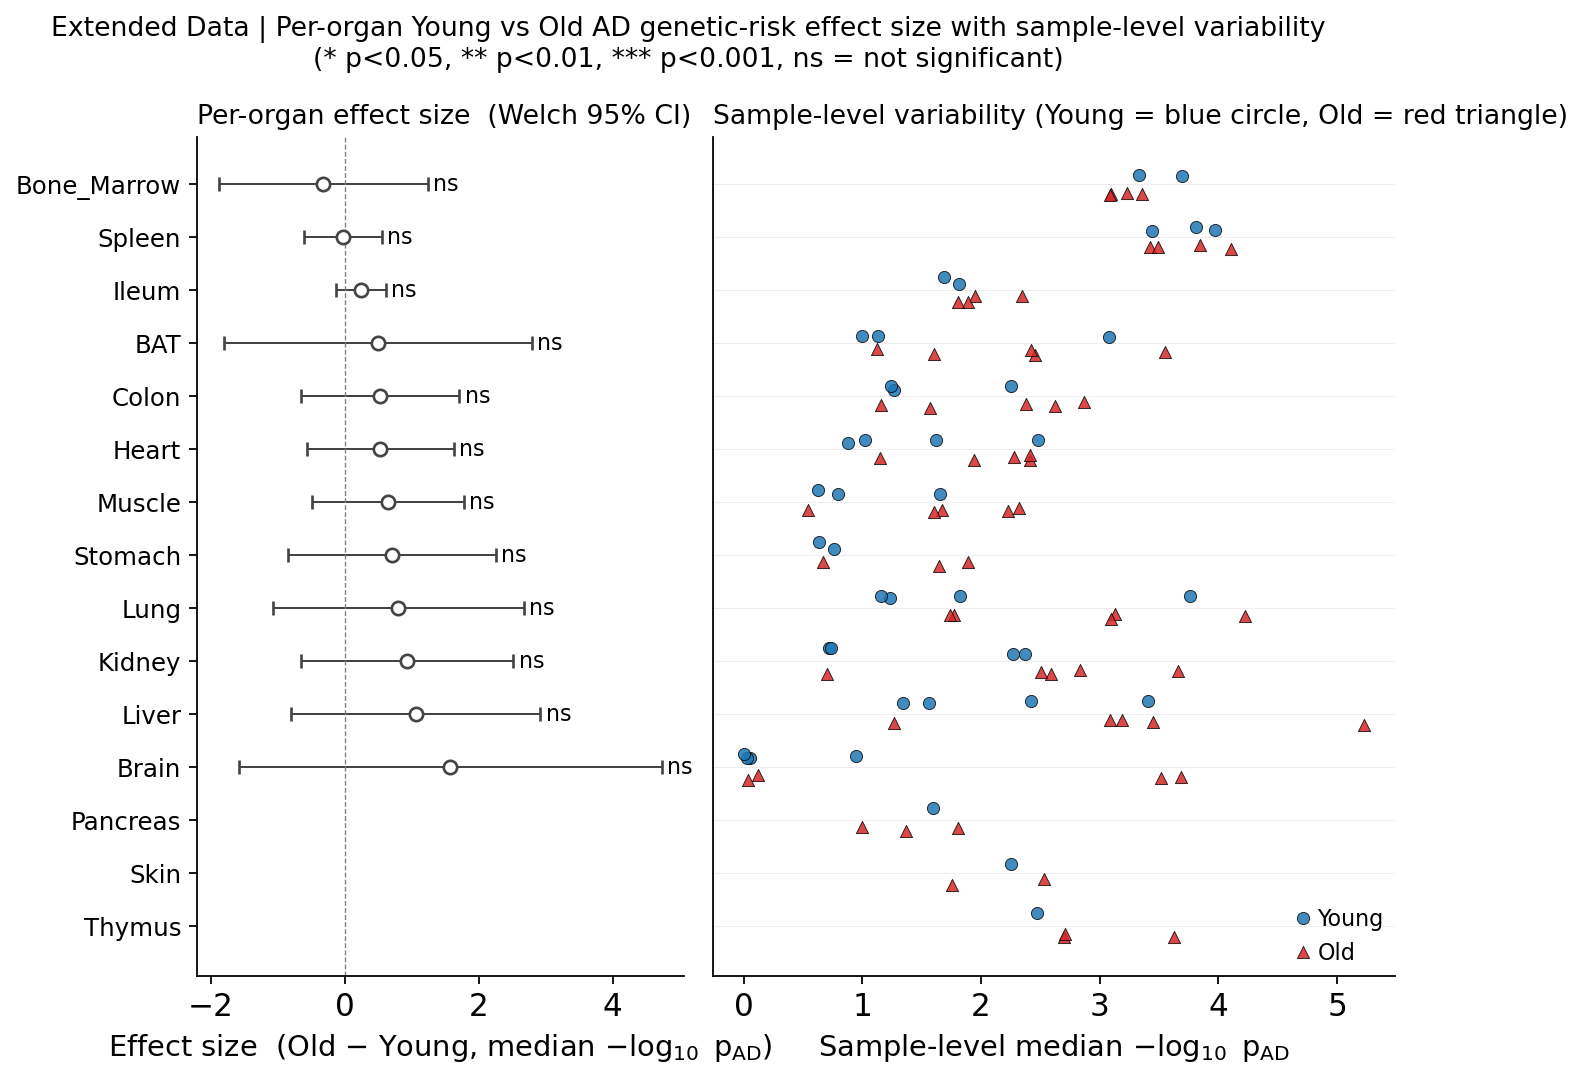


Significant organs (Welch p < 0.05):
  (none — confidence intervals overlap zero in every organ;
   per-organ sample sizes are small and Old-Young differences are
   noisy at the sample-median level)


In [2]:
# === Extended Data Fig | Per-organ Young vs Old AD genetic-risk effect size ===
# Self-contained: reads precomputed sample-level medians from results/.
# To regenerate the input CSV from the full h5ad, run:
#   python scripts/merge_age_h5ad.py    # builds data/age_merged/*.h5ad (5.5 GB)
#   python -c "import scanpy as sc, pandas as pd, numpy as np; \
#       a = sc.read_h5ad('data/age_merged/age_all_organs_all_traits.h5ad'); \
#       o = a.obs[['organ','age_months','sample','p_AD']].dropna(); \
#       o['logp'] = -np.log10(pd.to_numeric(o['p_AD'], errors='coerce').clip(1e-30)); \
#       o['age_group'] = np.where(o['age_months']<=6,'Young', np.where(o['age_months']>=18,'Old','Mid')); \
#       o.groupby(['organ','age_group','age_months','sample'])['logp'].median().reset_index() \
#         .rename(columns={'logp':'sample_median_logp'}) \
#         .to_csv('results/age_sample_medians_per_organ.csv', index=False)"
#
# Supports Paragraph 3 S3:
#   "age-resolved maps showed broad changes in spatial genetic-risk patterns
#    across organs, motivating an organ- and cell-type-level analysis rather
#    than interpretation from a single whole-body risk map alone."

samp_all = pd.read_csv(f'{RES}/age_sample_medians_per_organ.csv')
samp = samp_all[samp_all['age_group'].isin(['Young','Old'])].copy()
print(f'sample-level rows: {len(samp)}  (organs={samp["organ"].nunique()})')

# Effect size + 95% CI per organ via Welch t-test
rows = []
for organ, g in samp.groupby('organ', observed=True):
    y = g.loc[g['age_group']=='Young', 'sample_median_logp'].values
    o = g.loc[g['age_group']=='Old',   'sample_median_logp'].values
    if len(y) < 2 or len(o) < 2:
        rows.append({'organ': organ, 'effect': np.nan, 'ci_lo': np.nan,
                     'ci_hi': np.nan, 'n_young': len(y), 'n_old': len(o),
                     'p_welch': np.nan})
        continue
    effect = o.mean() - y.mean()
    s2y, s2o = y.var(ddof=1), o.var(ddof=1)
    se = np.sqrt(s2y/len(y) + s2o/len(o))
    df_w = (s2y/len(y) + s2o/len(o))**2 / (
        (s2y/len(y))**2/(len(y)-1) + (s2o/len(o))**2/(len(o)-1))
    tcrit = stats.t.ppf(0.975, df=df_w)
    ci_lo, ci_hi = effect - tcrit*se, effect + tcrit*se
    _, p = stats.ttest_ind(o, y, equal_var=False)
    rows.append({'organ': organ, 'effect': effect, 'ci_lo': ci_lo,
                 'ci_hi': ci_hi, 'n_young': len(y), 'n_old': len(o),
                 'p_welch': p})
eff = (pd.DataFrame(rows)
         .sort_values('effect', ascending=True, na_position='last')
         .reset_index(drop=True))
print(eff.round(3))

fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(9.6, max(3.5, 0.36*len(eff)+1.5)),
    gridspec_kw={'width_ratios': [1.0, 1.4], 'wspace': 0.05},
    sharey=True,
)
y_pos = np.arange(len(eff))

# --- Left: forest ---
finite = eff['effect'].notna()
axL.errorbar(eff.loc[finite,'effect'], y_pos[finite],
             xerr=[eff.loc[finite,'effect'] - eff.loc[finite,'ci_lo'],
                   eff.loc[finite,'ci_hi'] - eff.loc[finite,'effect']],
             fmt='o', color='#444', ecolor='#444', capsize=3, lw=0.9, ms=6,
             markerfacecolor='white', markeredgewidth=1.2)
axL.axvline(0, color='grey', lw=0.6, ls='--')
axL.set_yticks(y_pos)
axL.set_yticklabels(eff['organ'].values, fontsize=TICK_FS-1)
axL.set_xlabel(r'Effect size  (Old $-$ Young, median $-\log_{10}$ p$_{\rm AD}$)',
               fontsize=LABEL_FS)
axL.invert_yaxis()
axL.spines['top'].set_visible(False); axL.spines['right'].set_visible(False)
for i, (p, ci_hi) in enumerate(zip(eff['p_welch'], eff['ci_hi'])):
    if pd.isna(p): continue
    star = ('***' if p < 0.001 else
            '**'  if p < 0.01  else
            '*'   if p < 0.05  else 'ns')
    x_at = ci_hi + 0.08 if pd.notna(ci_hi) else 0
    axL.text(x_at, i, star, va='center', ha='left',
             fontsize=TEXT_FS-1, color='black')
axL.set_title('Per-organ effect size  (Welch 95% CI)',
              fontsize=TITLE_FS-1, loc='left')

# --- Right: sample dots ---
np.random.seed(0)
for i, organ in enumerate(eff['organ'].values):
    for grp, color, marker, jitter in [
        ('Young', '#1f77b4', 'o', -0.18),
        ('Old',   '#d62728', '^', +0.18),
    ]:
        vals = samp.loc[(samp['organ']==organ) & (samp['age_group']==grp),
                        'sample_median_logp'].values
        if len(vals) == 0: continue
        ys = i + jitter + (np.random.rand(len(vals)) - 0.5) * 0.15
        axR.scatter(vals, ys, color=color, marker=marker, s=30,
                    edgecolor='black', lw=0.4, alpha=0.85,
                    label=grp if i == 0 else None)
axR.set_xlabel(r'Sample-level median $-\log_{10}$ p$_{\rm AD}$',
               fontsize=LABEL_FS)
axR.set_title('Sample-level variability (Young = blue circle, Old = red triangle)',
              fontsize=TITLE_FS-1, loc='left')
axR.spines['top'].set_visible(False); axR.spines['right'].set_visible(False)
axR.tick_params(left=False, labelleft=False)
axR.legend(loc='lower right', frameon=False, fontsize=LEGEND_FS-1)
for i in range(len(eff)):
    axR.axhline(i, color='#eeeeee', lw=0.5, zorder=0)

fig.suptitle('Extended Data | Per-organ Young vs Old AD genetic-risk '
             'effect size with sample-level variability\n'
             '(* p<0.05, ** p<0.01, *** p<0.001, ns = not significant)',
             fontsize=TITLE_FS-1, y=1.02)
plt.tight_layout()
save_panel(fig, 'FigE_organ_young_vs_old_effect')
plt.show()

print('\nSignificant organs (Welch p < 0.05):')
sig = eff[eff['p_welch'] < 0.05].sort_values('effect', ascending=False)
if len(sig) == 0:
    print('  (none — confidence intervals overlap zero in every organ;\n'
          '   per-organ sample sizes are small and Old-Young differences are\n'
          '   noisy at the sample-median level)')
else:
    for _, r in sig.iterrows():
        direction = 'Old > Young' if r["effect"] > 0 else 'Young > Old'
        print(f'  {r["organ"]:<14}  Δ={r["effect"]:+.2f}  '
              f'[{r["ci_lo"]:+.2f}, {r["ci_hi"]:+.2f}]  p={r["p_welch"]:.3g}  '
              f'{direction}')


## Supplementary Fig — Composition control across 5 organs (Para 4 S3)


     organ  n_total_spots  n_myeloid  pct_myeloid  n_epithelial  \
0    Brain          72929      25836        35.43           138   
1     Lung          75282      22340        29.68         17661   
2    Liver          58149       6490        11.16         40820   
3  Stomach          74115       1771         2.39          4057   
4    Colon          70198       1755         2.50         42746   

   pct_epithelial  myeloid_best_logp  epithelial_best_logp  epi_minus_mye_logp  
0            0.19               8.36                  0.04               -8.32  
1           23.46               9.11                  5.57               -3.54  
2           70.20               8.06                  4.92               -3.13  
3            5.47               5.40                  1.60               -3.81  
4           60.89               4.42                  6.33                1.91  


  saved -> FigS_composition_control_5organs.{pdf,png,svg}


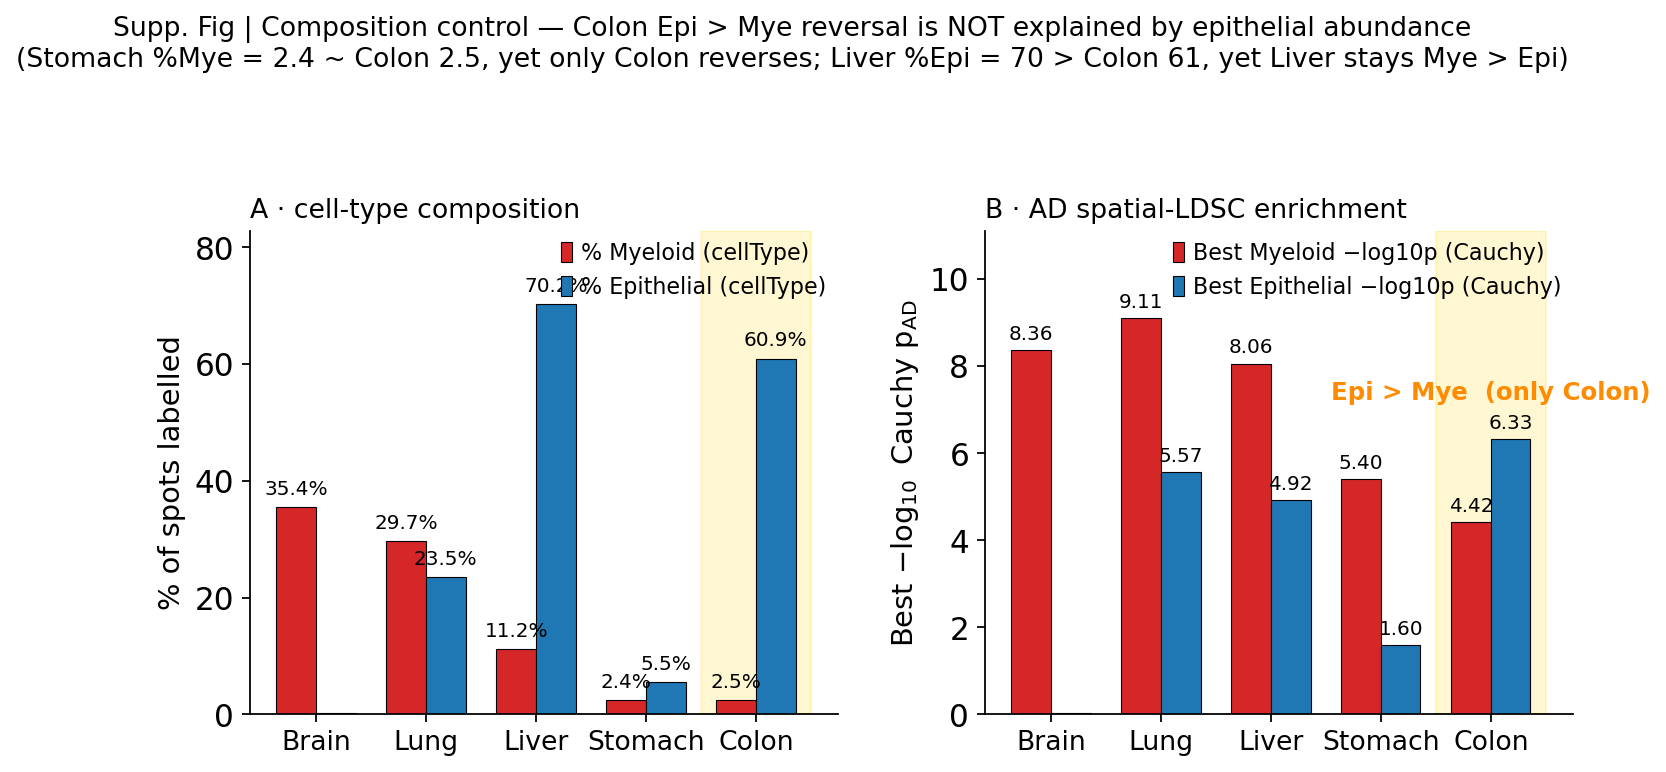


Key contrasts:
  Colon   vs Stomach (similar %Myeloid): Colon %Mye=2.5 vs Stomach 2.4 — Colon Epi/Mye=6.33/4.42 (REVERSED); Stomach 1.60/5.40 (not)
  Colon   vs Liver  (similar %Epithelial): Colon %Epi=60.9 vs Liver 70.2 — Liver Epi/Mye=4.92/8.06 (not reversed)


In [3]:
# === Supplementary Fig | Composition control across 5 organs ===
# Side-by-side 2-panel chart for Brain, Lung, Liver, Stomach, Colon:
#   Left  — composition fractions (%myeloid vs %epithelial) from cellType labels
#   Right — best -log10 Cauchy p_AD per class (myeloid vs epithelial)
# Demonstrates that the Colon Epi > Mye reversal is NOT a generic consequence
# of epithelial abundance:
#   - Liver has higher %epithelial (70%) than Colon (61%) but still Mye > Epi.
#   - Stomach has the same %myeloid (2.4%) as Colon (2.5%) but still Mye > Epi.
# → only Colon shows the qualitative reversal.
#
# Supports Paragraph 4 S3.

comp = pd.read_csv(f'{RES}/composition_control_5organs.csv')
# Order: keep paragraph order Brain, Lung, Liver, Stomach, Colon
ORDER = ['Brain','Lung','Liver','Stomach','Colon']
comp = comp.set_index('organ').loc[ORDER].reset_index()
print(comp.round(2))

fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(10.6, 4.8),
    gridspec_kw={'wspace': 0.25},
)
x = np.arange(len(comp)); w = 0.36
MYE_C, EPI_C = '#d62728', '#1f77b4'

# --- Left: composition fractions ---
b1 = axL.bar(x - w/2, comp['pct_myeloid'],    w, color=MYE_C,
             edgecolor='black', lw=0.5, label='% Myeloid (cellType)')
b2 = axL.bar(x + w/2, comp['pct_epithelial'], w, color=EPI_C,
             edgecolor='black', lw=0.5, label='% Epithelial (cellType)')
for bars in (b1, b2):
    for b in bars:
        h = b.get_height()
        if h > 0.3:
            axL.text(b.get_x() + b.get_width()/2, h + 1.5, f'{h:.1f}%',
                     ha='center', va='bottom', fontsize=TEXT_FS-2)
# Highlight Colon column
if 'Colon' in comp['organ'].values:
    ci = list(comp['organ']).index('Colon')
    axL.axvspan(ci - 0.5, ci + 0.5, color='gold', alpha=0.18, zorder=0)
axL.set_xticks(x); axL.set_xticklabels(comp['organ'], fontsize=TICK_FS)
axL.set_ylabel('% of spots labelled', fontsize=LABEL_FS)
axL.set_title('A · cell-type composition',
              fontsize=TITLE_FS-1, loc='left')
axL.legend(loc='upper right', frameon=False, fontsize=LEGEND_FS-1)
axL.spines['top'].set_visible(False); axL.spines['right'].set_visible(False)
axL.set_ylim(0, max(comp['pct_myeloid'].max(), comp['pct_epithelial'].max()) * 1.18)

# --- Right: enrichment scores ---
b3 = axR.bar(x - w/2, comp['myeloid_best_logp'],    w, color=MYE_C,
             edgecolor='black', lw=0.5, label='Best Myeloid −log10p (Cauchy)')
b4 = axR.bar(x + w/2, comp['epithelial_best_logp'], w, color=EPI_C,
             edgecolor='black', lw=0.5, label='Best Epithelial −log10p (Cauchy)')
for bars in (b3, b4):
    for b in bars:
        h = b.get_height()
        if h > 0.05:
            axR.text(b.get_x() + b.get_width()/2, h + 0.15, f'{h:.2f}',
                     ha='center', va='bottom', fontsize=TEXT_FS-2)
# Highlight Colon
if 'Colon' in comp['organ'].values:
    ci = list(comp['organ']).index('Colon')
    axR.axvspan(ci - 0.5, ci + 0.5, color='gold', alpha=0.18, zorder=0)
    y_top = max(comp.loc[ci,'myeloid_best_logp'], comp.loc[ci,'epithelial_best_logp']) + 0.9
    axR.annotate('Epi > Mye  (only Colon)', xy=(ci, y_top), ha='center',
                 fontsize=TEXT_FS, fontweight='bold', color='darkorange')
axR.set_xticks(x); axR.set_xticklabels(comp['organ'], fontsize=TICK_FS)
axR.set_ylabel(r'Best $-\log_{10}$ Cauchy p$_{\rm AD}$', fontsize=LABEL_FS)
axR.set_title('B · AD spatial-LDSC enrichment',
              fontsize=TITLE_FS-1, loc='left')
axR.legend(loc='upper right', frameon=False, fontsize=LEGEND_FS-1)
axR.spines['top'].set_visible(False); axR.spines['right'].set_visible(False)
axR.set_ylim(0, max(comp['myeloid_best_logp'].max(),
                    comp['epithelial_best_logp'].max()) * 1.22)

plt.subplots_adjust(top=0.78)
fig.suptitle('Supp. Fig | Composition control — Colon Epi > Mye reversal '
             'is NOT explained by epithelial abundance\n'
             '(Stomach %Mye = 2.4 ~ Colon 2.5, yet only Colon reverses; '
             'Liver %Epi = 70 > Colon 61, yet Liver stays Mye > Epi)',
             fontsize=TITLE_FS-1, y=1.06)
plt.tight_layout()
save_panel(fig, 'FigS_composition_control_5organs')
plt.show()

print('\nKey contrasts:')
colon  = comp.set_index('organ').loc['Colon']
stom   = comp.set_index('organ').loc['Stomach']
liver  = comp.set_index('organ').loc['Liver']
print(f'  Colon   vs Stomach (similar %Myeloid): '
      f'Colon %Mye={colon["pct_myeloid"]:.1f} vs Stomach {stom["pct_myeloid"]:.1f} — '
      f'Colon Epi/Mye={colon["epithelial_best_logp"]:.2f}/{colon["myeloid_best_logp"]:.2f} '
      f'(REVERSED); Stomach {stom["epithelial_best_logp"]:.2f}/{stom["myeloid_best_logp"]:.2f} (not)')
print(f'  Colon   vs Liver  (similar %Epithelial): '
      f'Colon %Epi={colon["pct_epithelial"]:.1f} vs Liver {liver["pct_epithelial"]:.1f} — '
      f'Liver Epi/Mye={liver["epithelial_best_logp"]:.2f}/{liver["myeloid_best_logp"]:.2f} (not reversed)')
